In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:

# ===================== 1. 定义参数与真实转移矩阵 =====================
n_states = 4  # 4个状态：春(0)、夏(1)、秋(2)、冬(3)
# 真实转移矩阵（行：当前状态，列：下一个状态的概率）
P_true = np.array([
    [0.6, 0.3, 0.1, 0.0],
    [0.0, 0.7, 0.2, 0.1],
    [0.1, 0.0, 0.6, 0.3],
    [0.4, 0.1, 0.0, 0.5]
])

# ===================== 2. 生成训练数据 =====================
def generate_markov_seq(P, T=20000):
    """生成一阶马尔可夫链序列"""
    seq = [np.random.choice(n_states)]  # 随机初始状态
    for _ in range(T-1):
        next_state = np.random.choice(n_states, p=P[seq[-1]])
        seq.append(next_state)
    return np.array(seq)

# 生成20000长度的序列，构造(x_{t-1}, x_t)训练对
seq = generate_markov_seq(P_true)
X_train = torch.LongTensor(seq[:-1])  # 输入：前一状态
y_train = torch.LongTensor(seq[1:])   # 标签：当前状态

# ===================== 3. 定义自回归神经网络 =====================
class FourStateARNN(nn.Module):
    def __init__(self, n_states, hidden_dim=4):
        super().__init__()
        self.embedding = nn.Embedding(n_states, hidden_dim)  # 状态嵌入
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_states)  # 输出4个状态的logits
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch_size,) → 输出: (batch_size, n_states)
        h = self.embedding(x)
        h = self.relu(self.fc1(h))
        logits = self.fc2(h)
        return logits

# 初始化模型、损失函数、优化器
model = FourStateARNN(n_states)
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵（拟合条件概率）
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# ===================== 4. 训练模型 =====================
def train_model(model, X, y, epochs=150, batch_size=512):
    model.train()
    dataset = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        total_loss = 0.0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch_X.size(0)
        
        avg_loss = total_loss / len(X)
        if (epoch + 1) % 30 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")



In [3]:
# 启动训练
train_model(model, X_train, y_train)

Epoch 30/150, Average Loss: 0.9105
Epoch 60/150, Average Loss: 0.8863
Epoch 90/150, Average Loss: 0.8811
Epoch 120/150, Average Loss: 0.8788
Epoch 150/150, Average Loss: 0.8777


采样序列前20步： [0 2 3 0 0 0 0 1 1 1 1 1 1 1 1 2 3 3 1 2]

=== 验证结果 ===
真实转移矩阵：
[[0.6 0.3 0.1 0. ]
 [0.  0.7 0.2 0.1]
 [0.1 0.  0.6 0.3]
 [0.4 0.1 0.  0.5]]
经验转移矩阵（采样序列）：
[[0.61 0.3  0.09 0.  ]
 [0.   0.69 0.19 0.12]
 [0.07 0.   0.59 0.34]
 [0.4  0.08 0.01 0.52]]
转移矩阵均方误差（MSE）：0.0002 (越小越好，<0.01为拟合良好)
卡方检验p值：0.0000 (p>0.05则接受原假设，说明拟合一致)


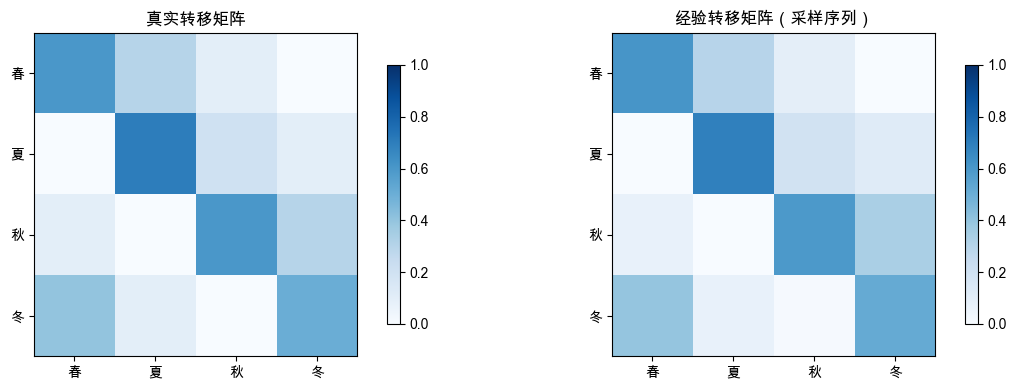


稳态分布对比：
真实稳态分布（春/夏/秋/冬）：[0.255 0.321 0.224 0.199]
采样序列状态占比：[0.264 0.306 0.209 0.221]


In [4]:


# ===================== 5. 采样生成新序列 =====================
def sample_arnn_sequence(model, init_state, seq_len=1000):
    """用训练好的ARNN采样生成序列"""
    model.eval()
    sampled_seq = [init_state]
    with torch.no_grad():
        for _ in range(seq_len - 1):
            # 输入前一状态，预测转移概率
            x = torch.LongTensor([sampled_seq[-1]])
            logits = model(x)
            probs = torch.softmax(logits, dim=1).numpy()[0]  # 转为概率分布
            next_state = np.random.choice(n_states, p=probs)
            sampled_seq.append(next_state)
    return np.array(sampled_seq)

# 从状态0（春）开始采样1000步
sampled_seq = sample_arnn_sequence(model, init_state=0, seq_len=1000)
print("采样序列前20步：", sampled_seq[:20])

# ===================== 6. 验证方法：量化+可视化 =====================
def validate_markov_fit(P_true, sampled_seq, n_states):
    """验证ARNN拟合的转移矩阵与真实矩阵的一致性"""
    # 步骤1：统计采样序列的转移计数（构建经验转移矩阵）
    transition_counts = np.zeros((n_states, n_states))
    for t in range(len(sampled_seq)-1):
        curr_state = sampled_seq[t]
        next_state = sampled_seq[t+1]
        transition_counts[curr_state, next_state] += 1
    
    # 步骤2：转为经验转移概率矩阵
    P_empirical = transition_counts / transition_counts.sum(axis=1, keepdims=True)
    P_empirical = np.nan_to_num(P_empirical)  # 处理0分母（实际不会出现）
    
    # 步骤3：计算拟合误差（均方误差MSE）
    mse = np.mean((P_true - P_empirical)**2)
    print(f"\n=== 验证结果 ===")
    print(f"真实转移矩阵：\n{P_true.round(2)}")
    print(f"经验转移矩阵（采样序列）：\n{P_empirical.round(2)}")
    print(f"转移矩阵均方误差（MSE）：{mse:.4f} (越小越好，<0.01为拟合良好)")
    
    # 步骤4：卡方检验（验证转移分布一致性）
    # 原假设：采样序列的转移分布与真实分布一致
    chi2, p_value, dof, _ = chi2_contingency(transition_counts)
    print(f"卡方检验p值：{p_value:.4f} (p>0.05则接受原假设，说明拟合一致)")
    
    # 步骤5：可视化对比（真实vs经验转移矩阵）
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    im1 = ax1.imshow(P_true, cmap="Blues", vmin=0, vmax=1)
    ax1.set_title("真实转移矩阵")
    ax1.set_xticks(range(n_states))
    ax1.set_yticks(range(n_states))
    ax1.set_xticklabels(["春", "夏", "秋", "冬"])
    ax1.set_yticklabels(["春", "夏", "秋", "冬"])
    
    im2 = ax2.imshow(P_empirical, cmap="Blues", vmin=0, vmax=1)
    ax2.set_title("经验转移矩阵（采样序列）")
    ax2.set_xticks(range(n_states))
    ax2.set_yticks(range(n_states))
    ax2.set_xticklabels(["春", "夏", "秋", "冬"])
    ax2.set_yticklabels(["春", "夏", "秋", "冬"])
    
    # 添加颜色条
    fig.colorbar(im1, ax=ax1, shrink=0.8)
    fig.colorbar(im2, ax=ax2, shrink=0.8)
    plt.tight_layout()
    plt.show()
    
    # 步骤6：状态占比验证（一阶马尔可夫链的稳态分布）
    # 计算真实稳态分布（解πP=π）
    eigvals, eigvecs = np.linalg.eig(P_true.T)
    steady_idx = np.where(np.isclose(eigvals, 1))[0][0]
    steady_true = eigvecs[:, steady_idx].real
    steady_true = steady_true / steady_true.sum()
    
    # 计算采样序列的状态占比
    steady_sampled = np.bincount(sampled_seq) / len(sampled_seq)
    
    print(f"\n稳态分布对比：")
    print(f"真实稳态分布（春/夏/秋/冬）：{steady_true.round(3)}")
    print(f"采样序列状态占比：{steady_sampled.round(3)}")

# 执行验证
validate_markov_fit(P_true, sampled_seq, n_states)